In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.datasets import CIFAR10
import numpy as np
from torch.utils.data import random_split, DataLoader
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# Setting up CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
train_val = [0.75, 0.25]
batch_size = 64
l_r = 1e-3
epochs = 75
input_channels = 3
no_of_classes = 10

# Data Preprocessing

In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5),
])
test_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, ), (0.5,))])

train_data = CIFAR10(root="./dataset", train=True, download=True, transform=train_transform)
test_data = CIFAR10(root="./dataset", train=False, download=True, transform=test_transform)

train_data, val_data = random_split(train_data, train_val)

In [5]:
train_dl = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_dl = DataLoader(test_data, batch_size=batch_size)
val_dl = DataLoader(val_data, batch_size=batch_size)

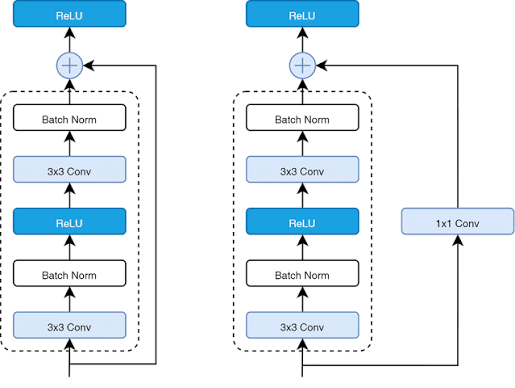

In [6]:
class ResNetBlock(nn.Module):
    def __init__(self, input_size, output_size, strides=1, conv1x1=False):
        super().__init__()
        self.conv1x1 = conv1x1
        
        self.conv1 = nn.Conv2d(input_size, output_size, kernel_size=3, padding=1, stride=strides)
        self.batchnorm1 = nn.BatchNorm2d(output_size)
        self.relu = nn.ReLU()
        
        self.conv2 = nn.Conv2d(output_size, output_size, kernel_size=3, padding=1)
        self.batchnorm2 = nn.BatchNorm2d(output_size)
        
        if conv1x1:
            self.conv3 = nn.Conv2d(input_size, output_size, kernel_size=1, stride=strides) 

    def forward(self, X): 
        Y = self.conv1(X)
        Y = self.batchnorm1(Y)
        Y = self.relu(Y)
        
        Y = self.conv2(Y)
        Y = self.batchnorm2(Y)
        
        if self.conv1x1:
            # For Projection Block
            X = self.conv3(X)
            
        Y += X
        return self.relu(Y) 

In [7]:
class ResNetStage(nn.Module):
    # Contains multiple ResNetBlocks
    def __init__(self, input_size, output_size, no_of_blocks, first_stage=False):
        super().__init__()
        blocks =[]

        if first_stage:
            blocks.append(ResNetBlock(input_size, output_size, strides=1))
        else:
            blocks.append(ResNetBlock(input_size, output_size, strides=2, conv1x1=True))
            
        for _ in range(no_of_blocks-1):
            blocks.append(ResNetBlock(output_size, output_size))

        self.stage = nn.Sequential(*blocks)

    def forward(self, X):
        return self.stage(X)

In [8]:
class ResNet(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        self.stem = nn.Sequential(nn.Conv2d(input_size, 32, kernel_size=3), nn.BatchNorm2d(32))

        stages = []
        
        stages.append(ResNetStage(32, 32, 3, True))
        stages.append(ResNetStage(32, 64, 3))
        stages.append(ResNetStage(64, 128, 3))
        stages.append(ResNetStage(128, 256, 1))

        self.stages = nn.Sequential(*stages)

        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.dropout = nn.Dropout(0.2)
        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(nn.Linear(256, 10))

    def forward(self, X):
        X = self.stem(X)
        X = self.stages(X)
        X = self.gap(X)
        X = self.dropout(X)
        X = self.flatten(X)
        Y = self.fc(X)

        return Y
        

In [9]:
model = ResNet(input_channels, no_of_classes).to(device)
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=l_r, 
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

In [10]:
def validate_model(model, dl, criterion):
    running_loss = 0
    model.eval()
    running_loss = 0
    crt_pred = 0
    preds = 0
    
    with torch.no_grad():
        for X, y in dl:
            X = X.to(device)
            y = y.to(device)
    
            y_hat = model(X)
            loss = criterion(y_hat, y)
    
            running_loss += loss.item()
            out = torch.argmax(y_hat, dim=1)
            crt_pred += (out == y).sum().item()
            preds += y.size(0)

    return running_loss/len(dl), crt_pred / preds

In [16]:
def evaluate_classifier(model, dataloader):
    class_names = [
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck"
    ]
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification Report
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)

    print("\n====== Classification Report ======\n")
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    fig, ax = plt.subplots(figsize=(10, 10))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

    plt.title("Confusion Matrix")
    plt.xticks(rotation=45)
    plt.show()


In [12]:
def train_model(dl, epochs, model, optimizer, loss_fn, val_dl):
    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        model.train()
        
        running_loss = 0
        crt_pred = 0
        preds = 0

        for X, y in dl:
            X = X.to(device)
            y = y.to(device)
            
            y_hat = model(X)
            loss = loss_fn(y_hat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            out = torch.argmax(y_hat, dim=1)
            crt_pred += (out == y).sum().item()
            preds += y.size(0)

        val_loss, val_acc = validate_model(model, val_dl, loss_fn)
        
        train_losses.append(running_loss / len(dl))
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        train_accs.append(crt_pred / preds)
        
        
        print(
            f"Epoch {epoch+1} | "
            f"Loss: {running_loss / len(dl):.4f} | "
            f"Accuracy: {crt_pred / preds:.4f} | "
            f"Validation Accuracy : {val_acc:.4f} |"
            f"Validation Loss : {val_loss}"
        )
    return train_accs, val_accs, train_losses, val_losses

In [13]:
train_Accs, val_Accs, train_Losses, val_Losses = train_model(train_dl, epochs, model, optimizer, criterion, val_dl)

Epoch 1 | Loss: 1.6189 | Accuracy: 0.3926 | Validation Accuracy : 0.4690 |Validation Loss : 1.4865183763358059
Epoch 2 | Loss: 1.1626 | Accuracy: 0.5784 | Validation Accuracy : 0.6237 |Validation Loss : 1.0720769407189623
Epoch 3 | Loss: 0.9648 | Accuracy: 0.6547 | Validation Accuracy : 0.7013 |Validation Loss : 0.8619442320599848
Epoch 4 | Loss: 0.8250 | Accuracy: 0.7127 | Validation Accuracy : 0.7044 |Validation Loss : 0.8586315765064589
Epoch 5 | Loss: 0.7252 | Accuracy: 0.7491 | Validation Accuracy : 0.7401 |Validation Loss : 0.7467258964874306
Epoch 6 | Loss: 0.6537 | Accuracy: 0.7739 | Validation Accuracy : 0.7527 |Validation Loss : 0.7134285325906715
Epoch 7 | Loss: 0.5983 | Accuracy: 0.7953 | Validation Accuracy : 0.7651 |Validation Loss : 0.6875755350504603
Epoch 8 | Loss: 0.5488 | Accuracy: 0.8118 | Validation Accuracy : 0.8112 |Validation Loss : 0.5564550342304366
Epoch 9 | Loss: 0.5159 | Accuracy: 0.8262 | Validation Accuracy : 0.8094 |Validation Loss : 0.5567935905894454
E

In [14]:
validate_model(model, val_dl, criterion)

(0.3812458789622297, 0.88496)


========== Classification Report ==========

              precision    recall  f1-score   support

    airplane     0.8968    0.8780    0.8873      1000
  automobile     0.9449    0.9440    0.9445      1000
        bird     0.8510    0.8510    0.8510      1000
         cat     0.8375    0.7370    0.7840      1000
        deer     0.8844    0.8720    0.8781      1000
         dog     0.8123    0.8700    0.8402      1000
        frog     0.8003    0.9660    0.8754      1000
       horse     0.9439    0.8920    0.9172      1000
        ship     0.9520    0.8920    0.9210      1000
       truck     0.9408    0.9370    0.9389      1000

    accuracy                         0.8839     10000
   macro avg     0.8864    0.8839    0.8838     10000
weighted avg     0.8864    0.8839    0.8838     10000



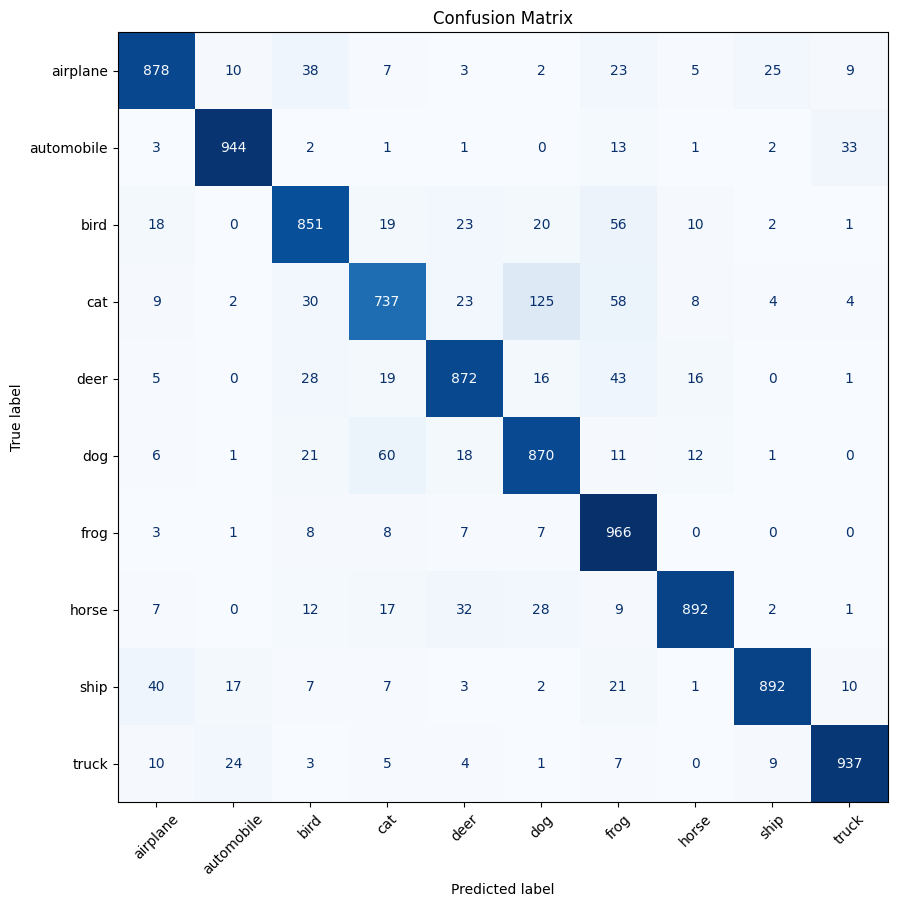

In [15]:
evaluate_classifier(model, test_dl)